# 제조 AI 에이전트용 특화 도구 구현

**과목**: AI 에이전트 시스템 설계 (X1-S4)  
**Lab**: 02 — 제조 도메인 특화 도구(Tool) 구현  
**난이도**: ⭐⭐⭐ 중급

---

AI 에이전트의 실질적인 능력은 **도구(Tool)**에서 나옵니다.  
일반적인 LLM이 "알고" 있는 것과 달리, 도구는 **실시간 데이터**에 접근하고 **실제 시스템**과 상호작용합니다.

이 노트북에서는 제조 현장 AI 에이전트가 활용할 도구 3종을 구현하고,  
이를 조합한 멀티-턴 대화 에이전트까지 완성합니다.

> ### 🎓 강사 가이드 — Lab 02 개요
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 전체 약 90분 |
> | 🎯 핵심 목표 | 실제 현장에서 쓸 수 있는 AI 에이전트 Tool 3개를 설계하고 구현 |
> | 🔑 핵심 개념 | Tool 설계 원칙: 명확한 입출력, 현장 연동 계층 분리 |
>
> **💡 강조 포인트**
> - 이 Lab의 Tool들은 Track A/B 신호와 직접 연결됩니다
> - "실제 파일 → fallback 시뮬레이션" 패턴으로 오프라인 환경에서도 동작합니다
>
> **❓ 생각해보기**: "지금 여러분의 현장에서 AI가 자동으로 조회하면 좋을 데이터는 어떤 게 있을까요?"


## 1. 학습 목표

이 Lab을 완료하면 다음을 할 수 있습니다:

| # | 학습 목표 | 핵심 개념 |
|---|-----------|----------|
| 1 | AI 에이전트용 도구 클래스를 설계하고 구현한다 | `name`, `description`, `run()` 인터페이스 |
| 2 | 센서 데이터, 품질 검사, 정비 이력 도구를 구현한다 | 시뮬레이션 데이터, 이상 감지 |
| 3 | 여러 도구를 통합하여 복합 문제를 해결하는 에이전트를 작성한다 | 도구 라우팅, 결과 연계 |
| 4 | 대화 이력을 유지하는 멀티-턴 에이전트를 구현한다 | `history`, 컨텍스트 관리 |
| 5 | 에이전트의 한계를 이해하고 Production 고려사항을 파악한다 | 신뢰성, 보안, 모니터링 |

**소요 시간**: 약 60-90분  
**사전 지식**: Python 기초, JSON, Lab 01 완료 권장

## 2. 제조 도메인 도구 설계 원칙

### 2.1 도구(Tool)란 무엇인가?

```
에이전트 (LLM)
    │
    ├── 도구 1: sensor_data_query  ──→  설비 센서 DB
    ├── 도구 2: quality_check      ──→  품질 관리 시스템 (QMS)
    └── 도구 3: maintenance_history ──→  설비 관리 시스템 (EAM)
```

도구는 에이전트가 외부 시스템에 접근하는 **인터페이스**입니다.  
에이전트는 어떤 도구를 언제 사용할지 결정하고, 도구는 실제 작업을 수행합니다.

### 2.2 좋은 도구의 4가지 원칙

**원칙 1: 단일 책임 (Single Responsibility)**
- 하나의 도구는 하나의 명확한 기능만 수행
- 예: `sensor_data_query`는 센서 데이터 조회만, 분석은 에이전트가 담당

**원칙 2: 명확한 인터페이스**
- `name`: 에이전트가 호출할 고유 이름 (영문 snake_case)
- `description`: LLM이 이해할 수 있는 한국어 설명 + 입력 형식
- `run(input)`: 실행 메서드, JSON 문자열 또는 dict 입력

**원칙 3: 견고한 에러 처리**
- 잘못된 입력에도 의미 있는 오류 메시지 반환
- 예외를 조용히 삼키지 않음

**원칙 4: Mock → 실제 연동 전환 가능**
- 개발/교육 단계: 시뮬레이션 데이터
- 운영 단계: 실제 API/DB 연결로 교체

### 2.3 표준 도구 클래스 구조

```python
class MyTool:
    name = "tool_name"           # 고유 이름
    description = "설명 (입력 형식 포함)"  # LLM이 읽을 설명
    
    def run(self, input_str):    # 실행 메서드
        # 1. 입력 파싱
        # 2. 작업 수행
        # 3. 결과 반환 (JSON 문자열)
        pass
```

## 3. 기본 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime, timedelta
import json
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'AppleGothic'  # macOS 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

print("라이브러리 임포트 완료")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")

라이브러리 임포트 완료
NumPy 2.1.3 | Pandas 2.2.3


> ### 🎓 강사 가이드 — 도구 1: 센서 데이터 조회
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 20분 |
> | 🎯 핵심 목표 | 설비 센서 데이터를 Tool로 래핑하는 방법 이해 |
> | 🔑 핵심 개념 | `SensorDataTool`, 시계열 데이터, 임계값 비교 |
>
> **💡 강조 포인트**
> - 실제 환경: InfluxDB, OSIsoft PI에서 데이터를 가져옴
> - 이 실습: CSV 파일 또는 시뮬레이션 데이터로 대체
> - 중요한 것은 Tool의 인터페이스(입출력) 설계입니다
>
> **🚨 주의사항**: 센서 값이 이상치인지 판단하는 임계값은 현장 전문가와 함께 정해야 합니다


## 4. 도구 1: 센서 데이터 조회 도구

**목적**: 설비에 부착된 센서(온도, 진동, 압력)의 실시간/이력 데이터를 조회합니다.  
**현장 연동**: 실제 환경에서는 InfluxDB, OSIsoft PI, 또는 SCADA 시스템과 연결됩니다.

> **시뮬레이션 설계**: 마지막 6시간 데이터에 이상(온도 급상승 +15°C, 진동 증가 +0.8)을 주입하여  
> 에이전트가 이상을 탐지하는 시나리오를 재현합니다.

In [2]:
class SensorDataTool:
    """설비 센서 데이터 조회 도구"""
    name = "sensor_data_query"
    description = "설비 센서 데이터를 조회합니다. Input: {'machine_id': 'M001', 'hours': 24}"
    
    def run(self, input_str):
        """센서 데이터 시뮬레이션 반환"""
        try:
            params = json.loads(input_str) if isinstance(input_str, str) else input_str
            machine_id = params.get('machine_id', 'M001')
            hours = int(params.get('hours', 24))
        except:
            machine_id, hours = 'M001', 24
        
        # 시뮬레이션 데이터 생성
        timestamps = [datetime.now() - timedelta(hours=i) for i in range(hours, 0, -1)]
        base_temp = 75 + np.random.randn(hours) * 3
        vibration = 0.5 + np.random.randn(hours) * 0.1
        
        # 이상 주입 (마지막 6시간)
        if hours >= 6:
            base_temp[-6:] += 15  # 온도 급상승
            vibration[-6:] += 0.8  # 진동 증가
        
        df = pd.DataFrame({
            'timestamp': timestamps,
            'temperature': base_temp,
            'vibration': vibration,
            'pressure': 2.0 + np.random.randn(hours) * 0.05
        })
        
        result = {
            'machine_id': machine_id,
            'period_hours': hours,
            'latest_temp': round(float(base_temp[-1]), 1),
            'latest_vibration': round(float(vibration[-1]), 3),
            'temp_trend': 'rising' if base_temp[-1] > base_temp[-6] else 'stable',
            'alert': bool(base_temp[-1] > 85 or vibration[-1] > 1.0)  # numpy.bool_ → bool
        }
        return json.dumps(result, ensure_ascii=False)


# 도구 테스트
sensor_tool = SensorDataTool()
print(f"도구 이름: {sensor_tool.name}")
print(f"도구 설명: {sensor_tool.description}")
print()

# 정상 조회 테스트
result = sensor_tool.run({'machine_id': 'M001', 'hours': 24})
data = json.loads(result)
print("센서 데이터 조회 결과:")
for k, v in data.items():
    print(f"  {k}: {v}")

alert_status = "⚠️ 알람 발생!" if data['alert'] else "✅ 정상 범위"
print(f"\n상태: {alert_status}")

도구 이름: sensor_data_query
도구 설명: 설비 센서 데이터를 조회합니다. Input: {'machine_id': 'M001', 'hours': 24}

센서 데이터 조회 결과:
  machine_id: M001
  period_hours: 24
  latest_temp: 89.5
  latest_vibration: 1.253
  temp_trend: rising
  alert: True

상태: ⚠️ 알람 발생!


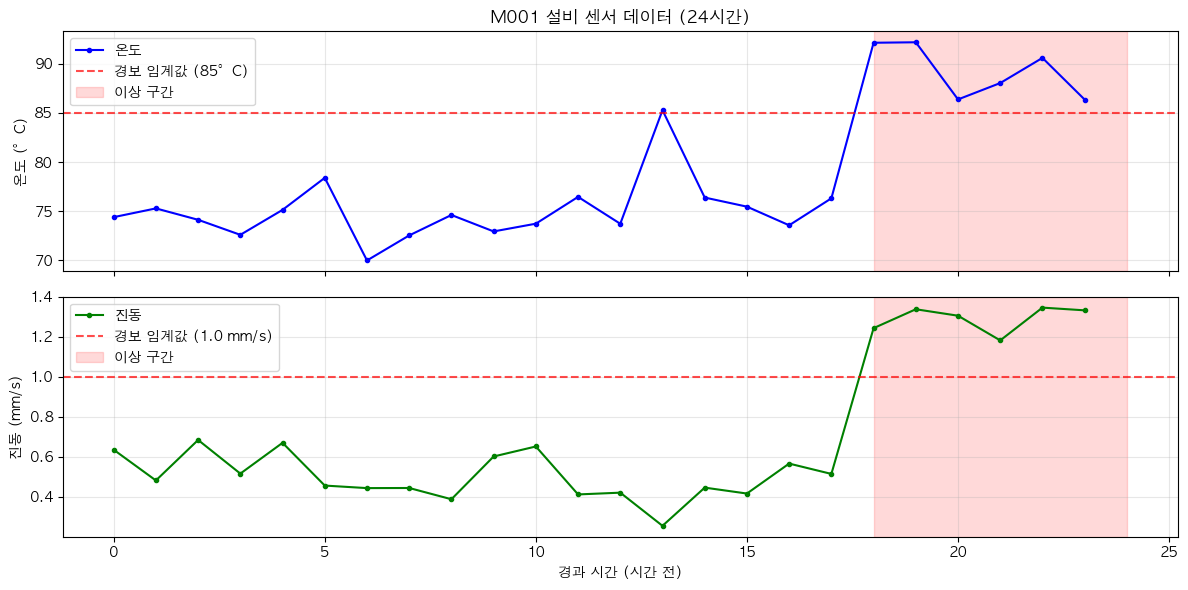

센서 데이터 시각화 완료


In [3]:
# 센서 데이터 시각화
hours = 24
timestamps = [datetime.now() - timedelta(hours=i) for i in range(hours, 0, -1)]
base_temp = 75 + np.random.randn(hours) * 3
vibration = 0.5 + np.random.randn(hours) * 0.1
base_temp[-6:] += 15
vibration[-6:] += 0.8

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(range(hours), base_temp, 'b-o', markersize=3, label='온도')
ax1.axhline(y=85, color='red', linestyle='--', alpha=0.7, label='경보 임계값 (85°C)')
ax1.axvspan(hours - 6, hours, alpha=0.15, color='red', label='이상 구간')
ax1.set_ylabel('온도 (°C)')
ax1.set_title('M001 설비 센서 데이터 (24시간)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(range(hours), vibration, 'g-o', markersize=3, label='진동')
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='경보 임계값 (1.0 mm/s)')
ax2.axvspan(hours - 6, hours, alpha=0.15, color='red', label='이상 구간')
ax2.set_ylabel('진동 (mm/s)')
ax2.set_xlabel('경과 시간 (시간 전)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensor_data_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("센서 데이터 시각화 완료")

> ### 🎓 강사 가이드 — 도구 2: 품질 검사
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 15분 |
> | 🎯 핵심 목표 | 생산 배치의 불량률과 불량 유형을 조회하는 Tool 설계 |
> | 🔑 핵심 개념 | 배치(Batch) 단위 품질 관리, 불량 유형 분류 |
>
> **💡 강조 포인트**
> - 실제 환경: 비전 검사 시스템(Vision Inspection System)과 연동
> - 불량률이 임계값을 초과하면 에이전트가 자동으로 경보를 발송할 수 있습니다
>
> **❓ 생각해보기**: "불량률 3%와 5%의 차이는 경제적으로 얼마나 다를까요? (일산 1000개 기준)"


## 5. 도구 2: 품질 검사 도구

**목적**: 생산 배치(Batch)의 품질 검사 결과를 분석하고 불량률, 불량 유형, 조치 여부를 반환합니다.  
**현장 연동**: 실제 환경에서는 비전 검사 시스템(Vision Inspection System) 또는 QMS API와 연결됩니다.

> **Beta 분포 사용**: 실제 제조 현장의 불량률 분포는 Beta 분포를 따르는 경향이 있습니다.  
> `np.random.beta(2, 20)`은 평균 약 9%의 불량률을 시뮬레이션합니다.

In [4]:
class QualityCheckTool:
    """제품 품질 검사 결과 분석 도구"""
    name = "quality_check"
    description = "제품 품질 검사 결과를 분석합니다. Input: {'product_id': 'P001', 'batch_size': 100}"
    
    def run(self, input_str):
        try:
            params = json.loads(input_str) if isinstance(input_str, str) else input_str
            product_id = params.get('product_id', 'P001')
            batch_size = int(params.get('batch_size', 100))
        except:
            product_id, batch_size = 'P001', 100
        
        defect_rate = float(np.random.beta(2, 20))  # float64 → float (JSON 직렬화 안전)
        defect_count = int(batch_size * defect_rate)
        
        defect_types = {
            '표면 스크래치': int(defect_count * 0.4),
            '치수 불량': int(defect_count * 0.3),
            '색상 불량': int(defect_count * 0.2),
            '기타': defect_count - int(defect_count * 0.9)
        }
        
        result = {
            'product_id': product_id,
            'batch_size': batch_size,
            'defect_count': defect_count,
            'defect_rate': round(defect_rate * 100, 2),
            'pass_rate': round((1 - defect_rate) * 100, 2),
            'defect_types': defect_types,
            'quality_grade': 'A' if defect_rate < 0.05 else ('B' if defect_rate < 0.1 else 'C'),
            'action_required': bool(defect_rate > 0.1)  # numpy.bool_ → bool
        }
        return json.dumps(result, ensure_ascii=False)


# 도구 테스트
quality_tool = QualityCheckTool()
print(f"도구 이름: {quality_tool.name}")
print(f"도구 설명: {quality_tool.description}")
print()

# 대용량 배치 테스트
result = quality_tool.run({'product_id': 'P-2026-001', 'batch_size': 500})
data = json.loads(result)
print("품질 검사 결과:")
for k, v in data.items():
    print(f"  {k}: {v}")

grade_emoji = {'A': '🥇', 'B': '🥈', 'C': '🥉'}.get(data['quality_grade'], '❓')
print(f"\n품질 등급: {grade_emoji} {data['quality_grade']}급")
if data['action_required']:
    print("⚠️ 조치 필요: 불량률이 10%를 초과했습니다.")

도구 이름: quality_check
도구 설명: 제품 품질 검사 결과를 분석합니다. Input: {'product_id': 'P001', 'batch_size': 100}

품질 검사 결과:
  product_id: P-2026-001
  batch_size: 500
  defect_count: 13
  defect_rate: 2.66
  pass_rate: 97.34
  defect_types: {'표면 스크래치': 5, '치수 불량': 3, '색상 불량': 2, '기타': 2}
  quality_grade: A
  action_required: False

품질 등급: 🥇 A급


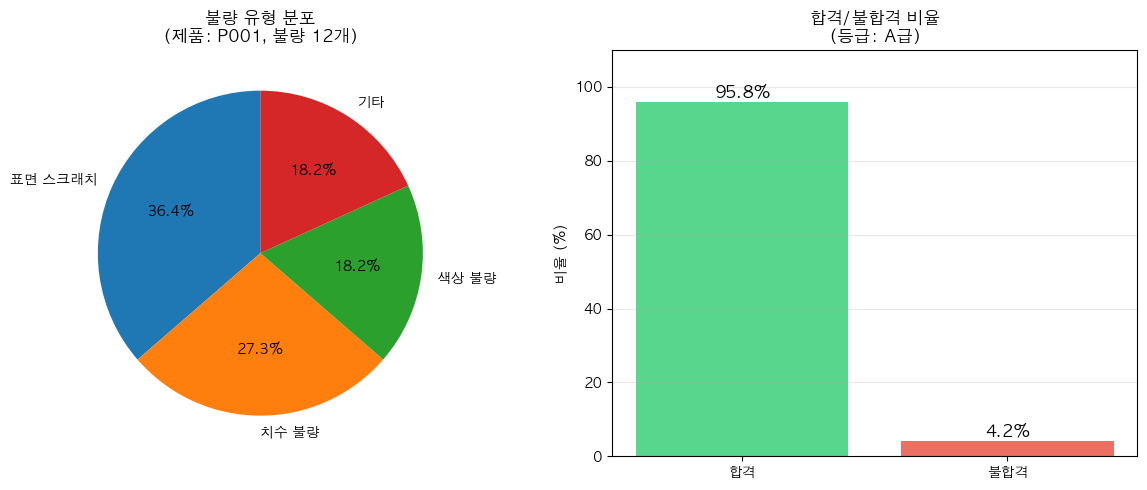

In [5]:
# 품질 불량 유형 시각화
result = quality_tool.run({'product_id': 'P001', 'batch_size': 300})
data = json.loads(result)

defect_types = data['defect_types']
labels = list(defect_types.keys())
sizes = list(defect_types.values())

# 0인 항목 제거
non_zero = [(l, s) for l, s in zip(labels, sizes) if s > 0]
if non_zero:
    labels_nz, sizes_nz = zip(*non_zero)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 파이 차트
    axes[0].pie(sizes_nz, labels=labels_nz, autopct='%1.1f%%', startangle=90)
    axes[0].set_title(f"불량 유형 분포\n(제품: {data['product_id']}, 불량 {data['defect_count']}개)")
    
    # 합격/불합격 비율 막대
    categories = ['합격', '불합격']
    values = [data['pass_rate'], data['defect_rate']]
    colors = ['#2ecc71', '#e74c3c']
    bars = axes[1].bar(categories, values, color=colors, alpha=0.8)
    axes[1].set_ylabel('비율 (%)')
    axes[1].set_title(f"합격/불합격 비율\n(등급: {data['quality_grade']}급)")
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=12)
    axes[1].set_ylim(0, 110)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('quality_check_visualization.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("불량이 없습니다! 완벽한 품질입니다.")

> ### 🎓 강사 가이드 — 도구 3: 정비 이력 조회
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 15분 |
> | 🎯 핵심 목표 | 설비 정비 이력을 조회하고 다음 정비 일정을 예측하는 Tool |
> | 🔑 핵심 개념 | CMMS(정비관리시스템), 예지보전, 정비 주기 |
>
> **💡 강조 포인트**
> - 마지막 정비일 + 정비 주기 = 다음 정비 예정일 계산
> - 긴급도(URGENT/NORMAL)는 이상 징후 + 정비 기한을 함께 고려합니다
>
> **❓ 생각해보기**: "예방정비(PM)와 예지정비(PdM)의 비용 차이를 계산할 수 있을까요?"


## 6. 도구 3: 정비 이력 조회 도구

**목적**: 설비의 정비 이력을 조회하고, 다음 정비 시기와 긴급도를 예측합니다.  
**현장 연동**: 실제 환경에서는 CMMS(Computerized Maintenance Management System) 또는 EAM(Enterprise Asset Management) API와 연결됩니다.

**긴급도 기준**:
- `LOW`: 정비 후 60일 이하 경과
- `MEDIUM`: 정비 후 61~80일 경과  
- `HIGH`: 정비 후 81일 이상 경과 (즉시 정비 필요)

In [6]:
class MaintenanceTool:
    """설비 정비 이력 및 예측 도구"""
    name = "maintenance_history"
    description = "설비 정비 이력을 조회하고 다음 정비 시기를 예측합니다. Input: {'machine_id': 'M001'}"
    
    def run(self, input_str):
        try:
            params = json.loads(input_str) if isinstance(input_str, str) else input_str
            machine_id = params.get('machine_id', 'M001')
        except:
            machine_id = 'M001'
        
        last_maintenance = datetime.now() - timedelta(days=np.random.randint(30, 90))
        days_since = (datetime.now() - last_maintenance).days
        
        result = {
            'machine_id': machine_id,
            'last_maintenance': last_maintenance.strftime('%Y-%m-%d'),
            'days_since_maintenance': days_since,
            'maintenance_interval_days': 90,
            'next_scheduled': (last_maintenance + timedelta(days=90)).strftime('%Y-%m-%d'),
            'days_until_maintenance': max(0, 90 - days_since),
            'urgency': 'HIGH' if days_since > 80 else ('MEDIUM' if days_since > 60 else 'LOW'),
            'recommendation': '즉시 정비 필요' if days_since > 80 else '정상 범위'
        }
        return json.dumps(result, ensure_ascii=False)


# 도구 테스트
maintenance_tool = MaintenanceTool()
print(f"도구 이름: {maintenance_tool.name}")
print(f"도구 설명: {maintenance_tool.description}")
print()

# 여러 설비 조회
machines = ['M001', 'M002', 'M003']
print("설비별 정비 현황:")
print("-" * 60)
for mid in machines:
    result = maintenance_tool.run({'machine_id': mid})
    data = json.loads(result)
    urgency_emoji = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}.get(data['urgency'], '⚪')
    print(f"{urgency_emoji} {mid}: 마지막 정비 {data['days_since_maintenance']}일 전 "
          f"| 다음 정비까지 {data['days_until_maintenance']}일 "
          f"| {data['urgency']} ({data['recommendation']})")

도구 이름: maintenance_history
도구 설명: 설비 정비 이력을 조회하고 다음 정비 시기를 예측합니다. Input: {'machine_id': 'M001'}

설비별 정비 현황:
------------------------------------------------------------
🟢 M001: 마지막 정비 40일 전 | 다음 정비까지 50일 | LOW (정상 범위)
🔴 M002: 마지막 정비 84일 전 | 다음 정비까지 6일 | HIGH (즉시 정비 필요)
🟡 M003: 마지막 정비 61일 전 | 다음 정비까지 29일 | MEDIUM (정상 범위)


> ### 🎓 강사 가이드 — 도구 통합: 복합 문제 해결 에이전트
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 15분 |
> | 🎯 핵심 목표 | 3개 Tool을 조합하여 복잡한 현장 문제를 자동 해결하는 에이전트 구현 |
> | 🔑 핵심 개념 | Tool 체이닝, 의사결정 트리, 자동화된 진단 |
>
> **💡 강조 포인트**
> - 에이전트가 센서 이상 → 품질 확인 → 정비 이력 조회 → 권고사항 생성 순으로 자동 실행됩니다
> - 사람이 30분 걸릴 진단을 에이전트가 30초에 수행합니다
>
> **❓ 생각해보기**: "이 에이전트를 24시간 자동으로 실행하면 어떤 이점이 있을까요?"


## 7. 도구 통합: 복합 문제 해결 에이전트

3개의 도구를 통합하여 실제 현장 시나리오를 처리하는 에이전트를 구현합니다.

**시나리오**: M002 설비에서 경보가 발생했을 때, 에이전트가 자동으로  
① 센서 데이터 확인 → ② 품질 영향 분석 → ③ 정비 긴급도 판단을 수행합니다.

In [7]:
class IntegratedManufacturingAgent:
    """3개 도구를 통합하는 제조 현장 에이전트"""
    
    def __init__(self):
        self.tools = {
            'sensor_data_query': SensorDataTool(),
            'quality_check': QualityCheckTool(),
            'maintenance_history': MaintenanceTool()
        }
        self.steps = []
    
    def _call_tool(self, tool_name, params):
        """도구 호출 및 결과 반환"""
        tool = self.tools.get(tool_name)
        if not tool:
            return {"error": f"도구 '{tool_name}'를 찾을 수 없습니다"}
        result_str = tool.run(params)
        return json.loads(result_str)
    
    def diagnose(self, machine_id, product_id):
        """설비 종합 진단 실행"""
        print(f"\n{'='*60}")
        print(f"  설비 종합 진단 시작: {machine_id}")
        print(f"{'='*60}")
        self.steps = []
        
        # Step 1: 센서 데이터 확인
        print("\n[Step 1] 센서 데이터 조회")
        sensor_data = self._call_tool('sensor_data_query', 
                                       {'machine_id': machine_id, 'hours': 24})
        alert = sensor_data.get('alert', False)
        temp = sensor_data.get('latest_temp', 0)
        vib = sensor_data.get('latest_vibration', 0)
        print(f"  온도: {temp}°C | 진동: {vib} mm/s | 알람: {'⚠️ 있음' if alert else '✅ 없음'}")
        self.steps.append({'step': 1, 'tool': 'sensor_data_query', 'result': sensor_data})
        
        # Step 2: 품질 영향 분석
        print("\n[Step 2] 품질 검사 분석")
        quality_data = self._call_tool('quality_check',
                                        {'product_id': product_id, 'batch_size': 200})
        grade = quality_data.get('quality_grade', 'N/A')
        defect_rate = quality_data.get('defect_rate', 0)
        print(f"  품질 등급: {grade} | 불량률: {defect_rate}%")
        self.steps.append({'step': 2, 'tool': 'quality_check', 'result': quality_data})
        
        # Step 3: 정비 이력 확인
        print("\n[Step 3] 정비 이력 조회")
        maint_data = self._call_tool('maintenance_history', {'machine_id': machine_id})
        urgency = maint_data.get('urgency', 'LOW')
        days_since = maint_data.get('days_since_maintenance', 0)
        print(f"  마지막 정비: {days_since}일 전 | 긴급도: {urgency}")
        self.steps.append({'step': 3, 'tool': 'maintenance_history', 'result': maint_data})
        
        # 종합 판단
        print(f"\n{'─'*60}")
        print("  종합 판단")
        print(f"{'─'*60}")
        
        risk_level = 0
        reasons = []
        
        if alert:
            risk_level += 3
            reasons.append(f"센서 알람 발생 (온도 {temp}°C, 진동 {vib} mm/s)")
        if grade == 'C' or defect_rate > 10:
            risk_level += 2
            reasons.append(f"품질 등급 {grade} (불량률 {defect_rate}%)")
        if urgency == 'HIGH':
            risk_level += 3
            reasons.append(f"정비 긴급 (마지막 정비 {days_since}일 전)")
        elif urgency == 'MEDIUM':
            risk_level += 1
            reasons.append(f"정비 필요 접근 ({days_since}일 경과)")
        
        if risk_level >= 5:
            final = "🚨 즉시 가동 중단 및 긴급 점검 필요"
        elif risk_level >= 3:
            final = "⚠️ 금일 내 점검 예약 권고"
        elif risk_level >= 1:
            final = "🔔 주의 관찰 필요, 익일 점검 계획"
        else:
            final = "✅ 정상 운전 가능"
        
        print(f"  종합 위험도: {risk_level}/8")
        if reasons:
            print("  위험 요인:")
            for r in reasons:
                print(f"    - {r}")
        print(f"\n  최종 조치: {final}")
        print(f"{'='*60}")
        
        return {'risk_level': risk_level, 'recommendation': final, 'steps': self.steps}


# 통합 에이전트 실행
agent = IntegratedManufacturingAgent()
diagnosis = agent.diagnose(machine_id='M002', product_id='P-2026-002')


  설비 종합 진단 시작: M002

[Step 1] 센서 데이터 조회
  온도: 87.4°C | 진동: 1.309 mm/s | 알람: ⚠️ 있음

[Step 2] 품질 검사 분석
  품질 등급: C | 불량률: 10.21%

[Step 3] 정비 이력 조회
  마지막 정비: 44일 전 | 긴급도: LOW

────────────────────────────────────────────────────────────
  종합 판단
────────────────────────────────────────────────────────────
  종합 위험도: 5/8
  위험 요인:
    - 센서 알람 발생 (온도 87.4°C, 진동 1.309 mm/s)
    - 품질 등급 C (불량률 10.21%)

  최종 조치: 🚨 즉시 가동 중단 및 긴급 점검 필요


> ### 🎓 강사 가이드 — 멀티-턴 대화 에이전트
>
> | 항목 | 내용 |
> |------|------|
> | ⏱️ 소요 시간 | 약 15분 |
> | 🎯 핵심 목표 | 이전 대화 맥락을 기억하며 연속 질문에 답하는 에이전트 구현 |
> | 🔑 핵심 개념 | `history` 관리, 대명사 해결 ("그 설비" → M002 설비) |
>
> **💡 강조 포인트**
> - "아까 말한 그 설비 온도 다시 확인해줘" 같은 자연스러운 대화가 가능해야 합니다
> - 대화 기록이 길어지면 LLM 컨텍스트 창을 초과할 수 있어 적절한 제한이 필요합니다


## 8. 멀티-턴 대화 에이전트

실제 현장에서는 작업자가 에이전트와 **대화하듯 질문**합니다.  
에이전트는 이전 대화 내용을 기억하면서 연속적인 질문에 답변해야 합니다.

**멀티-턴의 핵심**: `history` 리스트에 대화 이력을 누적하여 컨텍스트를 유지합니다.

In [8]:
class ConversationAgent:
    """대화 이력을 기억하는 에이전트"""
    def __init__(self, tools):
        self.tools = {t.name: t for t in tools}
        self.history = []
    
    def chat(self, user_input):
        self.history.append({'role': 'user', 'content': user_input})
        # 간단한 규칙 기반 라우팅
        response = self._process(user_input)
        self.history.append({'role': 'assistant', 'content': response})
        return response
    
    def _process(self, query):
        query_lower = query.lower()
        if '센서' in query or '온도' in query or '진동' in query:
            result = self.tools['sensor_data_query'].run({'machine_id': 'M001', 'hours': 24})
            data = json.loads(result)
            return (f"센서 데이터 조회 완료: 온도 {data['latest_temp']}°C, "
                    f"진동 {data['latest_vibration']}mm/s "
                    f"{'⚠️ 알람 발생!' if data['alert'] else '✅ 정상'}")
        elif '품질' in query or '불량' in query:
            result = self.tools['quality_check'].run({'product_id': 'P001', 'batch_size': 200})
            data = json.loads(result)
            return (f"품질 검사: 불량률 {data['defect_rate']}%, 등급 {data['quality_grade']} "
                    f"{'⚠️ 조치 필요' if data['action_required'] else '✅ 정상'}")
        elif '정비' in query or '유지보수' in query:
            result = self.tools['maintenance_history'].run({'machine_id': 'M001'})
            data = json.loads(result)
            return (f"정비 이력: 마지막 정비 {data['last_maintenance']}, "
                    f"다음 정비까지 {data['days_until_maintenance']}일 ({data['urgency']})")
        return "질문을 이해하지 못했습니다. '센서', '품질', '정비' 관련 질문을 해주세요."
    
    def show_history(self):
        """대화 이력 출력"""
        print("\n대화 이력:")
        print("─" * 50)
        for i, turn in enumerate(self.history):
            role_label = "👤 작업자" if turn['role'] == 'user' else "🤖 에이전트"
            print(f"[{i+1}] {role_label}: {turn['content']}")
        print(f"─" * 50)
        print(f"총 {len(self.history)}턴 대화")


# 멀티-턴 대화 시뮬레이션
conv_agent = ConversationAgent([
    SensorDataTool(),
    QualityCheckTool(),
    MaintenanceTool()
])

# 대화 시나리오
conversations = [
    "M001 설비 센서 상태 알려줘",
    "품질 검사 결과는 어때?",
    "정비는 언제 해야 해?",
    "온도가 높은데 위험한가?",  # 다시 센서 질문
]

print("멀티-턴 대화 시뮬레이션 시작")
print("=" * 50)
for question in conversations:
    print(f"\n👤 작업자: {question}")
    answer = conv_agent.chat(question)
    print(f"🤖 에이전트: {answer}")

# 대화 이력 확인
conv_agent.show_history()

멀티-턴 대화 시뮬레이션 시작

👤 작업자: M001 설비 센서 상태 알려줘
🤖 에이전트: 센서 데이터 조회 완료: 온도 84.7°C, 진동 1.29mm/s ⚠️ 알람 발생!

👤 작업자: 품질 검사 결과는 어때?
🤖 에이전트: 품질 검사: 불량률 3.95%, 등급 A ✅ 정상

👤 작업자: 정비는 언제 해야 해?
🤖 에이전트: 정비 이력: 마지막 정비 2025-12-30, 다음 정비까지 15일 (MEDIUM)

👤 작업자: 온도가 높은데 위험한가?
🤖 에이전트: 센서 데이터 조회 완료: 온도 91.8°C, 진동 1.176mm/s ⚠️ 알람 발생!

대화 이력:
──────────────────────────────────────────────────
[1] 👤 작업자: M001 설비 센서 상태 알려줘
[2] 🤖 에이전트: 센서 데이터 조회 완료: 온도 84.7°C, 진동 1.29mm/s ⚠️ 알람 발생!
[3] 👤 작업자: 품질 검사 결과는 어때?
[4] 🤖 에이전트: 품질 검사: 불량률 3.95%, 등급 A ✅ 정상
[5] 👤 작업자: 정비는 언제 해야 해?
[6] 🤖 에이전트: 정비 이력: 마지막 정비 2025-12-30, 다음 정비까지 15일 (MEDIUM)
[7] 👤 작업자: 온도가 높은데 위험한가?
[8] 🤖 에이전트: 센서 데이터 조회 완료: 온도 91.8°C, 진동 1.176mm/s ⚠️ 알람 발생!
──────────────────────────────────────────────────
총 8턴 대화


## 9. 에이전트 한계와 Production 배포 고려사항

### 9.1 현재 구현의 한계

| 한계 | 설명 | 영향 |
|------|------|------|
| **시뮬레이션 데이터** | 실제 센서/DB가 아닌 난수 생성 | 실제 이상 탐지 불가 |
| **규칙 기반 라우팅** | 키워드 매칭으로 도구 선택 | 복잡한 질의 처리 불가 |
| **단일 설비 처리** | 한 번에 하나의 설비만 분석 | 공장 전체 모니터링 불가 |
| **메모리 비영속성** | 프로세스 종료 시 이력 소멸 | 장기 트렌드 분석 불가 |
| **인증/권한 없음** | 누구나 모든 도구 사용 가능 | 보안 취약 |

### 9.2 Production 전환 체크리스트

**데이터 연결**
```python
# 시뮬레이션 → 실제 API 연결 예시
class SensorDataTool:
    def run(self, input_str):
        params = json.loads(input_str)
        # 실제 SCADA API 호출
        response = requests.get(
            f"http://scada.factory.com/api/sensors/{params['machine_id']}",
            params={'hours': params.get('hours', 24)},
            headers={'Authorization': f"Bearer {os.getenv('SCADA_TOKEN')}"}
        )
        return response.json()
```

**보안 강화**
- API 키는 환경변수(`.env`)에 저장, 코드에 하드코딩 금지
- 역할 기반 접근 제어(RBAC): 조회/실행 권한 분리
- 모든 에이전트 동작 감사 로그(Audit Log) 기록

**신뢰성**
- 타임아웃 설정: API 호출 시 최대 5초
- 재시도 로직: 실패 시 지수 백오프(Exponential Backoff)
- 서킷 브레이커: 연속 실패 시 도구 비활성화

**모니터링**
- 도구별 호출 횟수, 응답 시간, 오류율 추적
- LangSmith 또는 W&B Weave로 에이전트 실행 시각화
- 알람 기준 초과 시 Slack/Teams 알림 연동

### 9.3 LLM 기반 자동 라우팅으로 발전

현재 구현은 키워드 기반 라우팅입니다.  
실제 AI 에이전트에서는 LLM이 질의를 이해하고 최적 도구를 선택합니다:

```
사용자 질문
    │
    ▼
[LLM] "이 질문에 필요한 도구는?" → tool_selection
    │
    ▼
[Tool] 실행 및 결과 반환
    │
    ▼
[LLM] "결과를 자연어로 설명하면?" → final_answer
```

다음 Lab (Lab 03)에서 LangChain + OpenAI를 사용한 자동 라우팅을 구현합니다.

## 10. 학습 정리

### 핵심 개념 요약

```
에이전트 도구(Tool) 구조
┌─────────────────────────────────┐
│  class MyTool:                  │
│    name = "tool_name"           │  ← 에이전트가 호출할 이름
│    description = "설명..."       │  ← LLM이 도구 용도 파악에 사용
│    def run(self, input_str):    │  ← 실행 진입점
│        # 입력 파싱              │
│        # 작업 수행              │
│        return json.dumps(result)│  ← JSON 문자열 반환
└─────────────────────────────────┘
```

### 이 Lab에서 구현한 것

| 도구 | 역할 | 핵심 출력 |
|------|------|----------|
| `SensorDataTool` | 설비 센서 데이터 조회 | 온도, 진동, 알람 여부 |
| `QualityCheckTool` | 품질 검사 결과 분석 | 불량률, 등급, 불량 유형 |
| `MaintenanceTool` | 정비 이력 및 예측 | 긴급도, 다음 정비 일정 |
| `IntegratedManufacturingAgent` | 3개 도구 통합 진단 | 종합 위험도, 조치 권고 |
| `ConversationAgent` | 멀티-턴 대화 | 대화 이력 유지 |

### 도구 설계 4원칙 복습

1. **단일 책임**: 한 도구 = 한 기능
2. **명확한 인터페이스**: `name` + `description` + `run()`
3. **견고한 에러 처리**: 잘못된 입력에도 의미 있는 응답
4. **Mock → 실제 전환 가능**: 개발과 운영 코드 분리

### 다음 단계

- **Lab 03**: LangChain ReAct 에이전트로 자동 도구 선택 구현
- **Lab 04**: 실제 MES/QMS API 연동 및 인증 처리
- **Lab 05**: LangSmith로 에이전트 실행 추적 및 디버깅

---
*제조 AI 에이전트 교육과정 — 한국기술교육대학교*

---

## 📝 과제

### 기본 과제 (필수)

1. **Tool 직접 호출**: 노트북에 정의된 Tool 함수들을 직접 호출(Agent 없이)하여 각각의 반환값을 확인하세요.
   ```python
   result = query_quality_data("공정 A")
   print(result)
   ```

2. **위험도 점수 읽기**: `get_manufacturing_dashboard()`의 결과에서 `overall_risk_score`와 `overall_risk_level`을 출력하고, 현재 공장 상태가 어떤 수준인지 확인하세요.

### 심화 과제 (선택)

1. **신호 파일 수정**: `anomaly_signal.json` 또는 `rul_signal.json`에서 이상 점수를 높게(예: anomaly_score=0.9) 수정하고, 대시보드 위험도가 어떻게 바뀌는지 확인하세요.

### 제출 기준
- [ ] Tool 함수 직접 호출 완료
- [ ] 대시보드 위험도 점수 출력
- [ ] 각 Tool의 반환값 확인
